# 필요한 라이브러리 불러오기

In [9]:
import math
import torch
import matplotlib.pyplot as plt

# ❶ -pi부터 pi사이에서 점을 1000개 추출

In [10]:
x = torch.linspace(-math.pi, math.pi, 1000)

# ❷ 실제 사인곡선에서 추출한 값으로 y 만들기

In [11]:
y = torch.cos(x)
y = 3*x**3 + 2*x**2 -10*x + 41

# ❸ 임의의 가중치(계수)를 뽑아 예측용 y 만들기

In [12]:
a = torch.randn(())
b = torch.randn(())
c = torch.randn(())
d = torch.randn(())

# 사인 함수를 근사할 3차 다항식 정의

In [13]:
y_random = a * x**3 + b * x**2 + c * x + d

# 그래프 출력하기

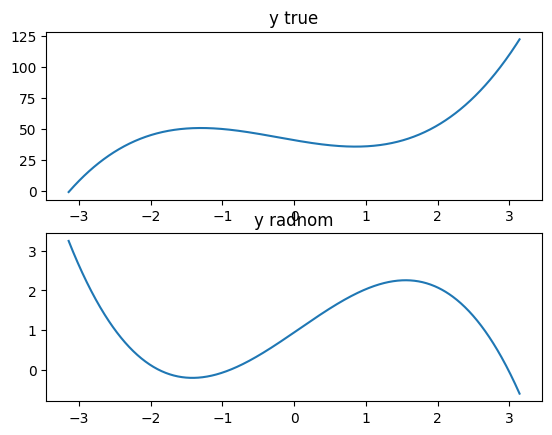

In [14]:
# ➍ 실제 y값으로 사인곡선 만들기
plt.subplot(2, 1, 1)
plt.title("y true")
plt.plot(x, y)

# ➎ 임의의 가중치로 만든 예측용 y값으로 사인곡선 만들기

plt.subplot(2, 1, 2)
plt.title("y radnom")
plt.plot(x, y_random)

# ➏ 그래프 출력하기
plt.show()

# 학습 전후 비교해보기

epoch1 loss:2616769.5
epoch101 loss:613515.6875
epoch201 loss:514199.3125
epoch301 loss:431292.1875
epoch401 loss:361785.8125
epoch501 loss:303508.03125
epoch601 loss:254639.9375
epoch701 loss:213658.125
epoch801 loss:179286.5625
epoch901 loss:150456.390625
epoch1001 loss:126271.953125
epoch1101 loss:105982.875
epoch1201 loss:88960.2265625
epoch1301 loss:74677.015625
epoch1401 loss:62691.41015625
epoch1501 loss:52632.9921875
epoch1601 loss:44191.109375
epoch1701 loss:37105.69921875
epoch1801 loss:31158.173828125
epoch1901 loss:26165.412109375


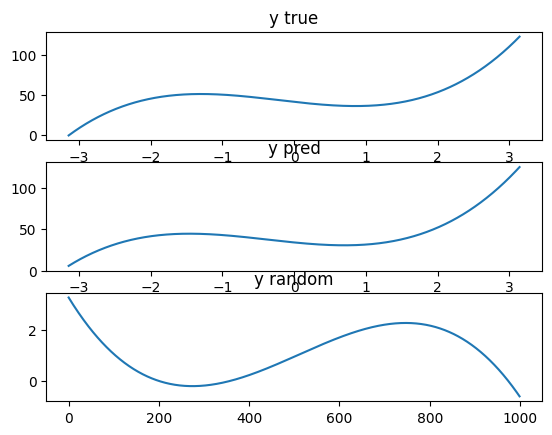

In [15]:
learning_rate = 1e-6 # 학습률 정의

for epoch in range(2000): # 학습 2000번 진행
   y_pred = a * x**3 + b * x**2 + c * x + d

   loss = (y_pred - y).pow(2).sum().item() # ❶ 손실 정의(MSE)
   if epoch % 100 == 0:
       print(f"epoch{epoch+1} loss:{loss}")

   grad_y_pred = 2.0 * (y_pred - y) # ❷ 손실함수(MSE)를 미분한 것
   grad_a = (grad_y_pred * x ** 3).sum()
   grad_b = (grad_y_pred * x ** 2).sum()
   grad_c = (grad_y_pred * x).sum()
   grad_d = grad_y_pred.sum()

   a -= learning_rate * grad_a # ❸ 가중치 업데이트
   b -= learning_rate * grad_b
   c -= learning_rate * grad_c
   d -= learning_rate * grad_d

plt.subplot(3, 1, 1)
plt.title("y true")
plt.plot(x, y)
plt.subplot(3, 1, 2)
plt.title("y pred")
plt.plot(x, y_pred)
plt.subplot(3, 1, 3)
plt.plot(y_random)
plt.title("y random")
plt.show()